In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.2.6


In [2]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [3]:
PROJECT_ROOT = Path(
    r"C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection"
)

WINDOW_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "CWRU"
    / "windows_corrected"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "vaac_tiny"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:")
print(PROJECT_ROOT)

print("\nCorrected window directory:")
print(WINDOW_DIR)

Project root:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection

Corrected window directory:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU\windows_corrected


In [4]:
FS = 12000
WINDOW_SIZE = 12000

CLASS_NAMES = [
    "Healthy",
    "Ball",
    "Inner Race",
    "Outer Race"
]

CLASS_TO_INDEX = {
    name: index
    for index, name in enumerate(CLASS_NAMES)
}

NUM_CLASSES = len(CLASS_NAMES)

print("Sampling frequency:", FS)
print("Window size:", WINDOW_SIZE)
print("Number of classes:", NUM_CLASSES)

Sampling frequency: 12000
Window size: 12000
Number of classes: 4


In [5]:
TRAIN_METADATA = (
    WINDOW_DIR
    / "train_metadata.csv"
)

VAL_METADATA = (
    WINDOW_DIR
    / "validation_metadata.csv"
)

TEST_METADATA = (
    WINDOW_DIR
    / "test_metadata.csv"
)

train_df = pd.read_csv(
    TRAIN_METADATA
)

val_df = pd.read_csv(
    VAL_METADATA
)

test_df = pd.read_csv(
    TEST_METADATA
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (232, 8)
Validation: (215, 8)
Test: (136, 8)


In [6]:
print("TRAIN")
print(train_df["class"].value_counts())

print("\nVALIDATION")
print(val_df["class"].value_counts())

print("\nTEST")
print(test_df["class"].value_counts())

TRAIN
class
Healthy       118
Inner Race     38
Outer Race     38
Ball           38
Name: count, dtype: int64

VALIDATION
class
Healthy       158
Outer Race     19
Ball           19
Inner Race     19
Name: count, dtype: int64

TEST
class
Healthy       79
Ball          19
Inner Race    19
Outer Race    19
Name: count, dtype: int64


In [7]:
def get_window_path(row, split):

    recording_id = str(
        row["recording_id"]
    )

    window_id = int(
        row["window_id"]
    )

    filename = (
        f"{recording_id}"
        f"_window_{window_id:04d}.npy"
    )

    return (
        WINDOW_DIR
        / split
        / filename
    )

In [8]:
def load_windows(
    metadata_df,
    split
):

    X = []
    y = []

    for _, row in metadata_df.iterrows():

        path = get_window_path(
            row,
            split
        )

        if not path.exists():
            raise FileNotFoundError(
                f"Window not found:\n{path}"
            )

        signal = np.load(path)

        if signal.shape != (
            WINDOW_SIZE,
        ):
            raise ValueError(
                f"Unexpected shape "
                f"{signal.shape}\n"
                f"File: {path}"
            )

        X.append(
            signal.astype(
                np.float32
            )
        )

        y.append(
            int(row["label"])
        )

    X = np.asarray(
        X,
        dtype=np.float32
    )

    y = np.asarray(
        y,
        dtype=np.int64
    )

    return X, y

In [9]:
print("Loading training windows...")

X_train, y_train = load_windows(
    train_df,
    "train"
)

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

Loading training windows...
X_train: (232, 12000)
y_train: (232,)


In [10]:
print("Loading validation windows...")

X_val, y_val = load_windows(
    val_df,
    "validation"
)

print(
    "X_val:",
    X_val.shape
)

print(
    "y_val:",
    y_val.shape
)

Loading validation windows...
X_val: (215, 12000)
y_val: (215,)


In [11]:
print("Loading test windows...")

X_test, y_test = load_windows(
    test_df,
    "test"
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_test:",
    y_test.shape
)

Loading test windows...
X_test: (136, 12000)
y_test: (136,)


In [12]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (232, 12000, 1)
X_val: (215, 12000, 1)
X_test: (136, 12000, 1)


In [13]:
def normalize_windows(X):

    rms = np.sqrt(
        np.mean(
            X ** 2,
            axis=1,
            keepdims=True
        )
    )

    X_normalized = (
        X / (rms + 1e-8)
    )

    return X_normalized.astype(
        np.float32
    )

In [14]:
X_train = normalize_windows(
    X_train
)

X_val = normalize_windows(
    X_val
)

X_test = normalize_windows(
    X_test
)

print("Normalization completed.")

Normalization completed.


In [15]:
train_rms = np.sqrt(
    np.mean(
        X_train ** 2,
        axis=1
    )
)

print(
    "Mean normalized RMS:",
    np.mean(train_rms)
)

print(
    "Minimum normalized RMS:",
    np.min(train_rms)
)

print(
    "Maximum normalized RMS:",
    np.max(train_rms)
)

Mean normalized RMS: 1.0
Minimum normalized RMS: 0.99999976
Maximum normalized RMS: 1.0


In [16]:
def build_vaac_tiny_cnn(
    input_length=12000,
    num_classes=4
):

    inputs = layers.Input(
        shape=(input_length, 1),
        name="vibration_input"
    )

    # Initial feature extraction
    x = layers.Conv1D(
        filters=16,
        kernel_size=7,
        padding="same",
        activation="relu",
        name="initial_conv"
    )(inputs)

    # -----------------------------------------
    # Multi-scale branch: kernel 3
    # -----------------------------------------

    branch_3 = layers.SeparableConv1D(
        filters=16,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="scale_3"
    )(x)

    # -----------------------------------------
    # Multi-scale branch: kernel 7
    # -----------------------------------------

    branch_7 = layers.SeparableConv1D(
        filters=16,
        kernel_size=7,
        padding="same",
        activation="relu",
        name="scale_7"
    )(x)

    # -----------------------------------------
    # Multi-scale branch: kernel 15
    # -----------------------------------------

    branch_15 = layers.SeparableConv1D(
        filters=16,
        kernel_size=15,
        padding="same",
        activation="relu",
        name="scale_15"
    )(x)

    # -----------------------------------------
    # Multi-scale fusion
    # -----------------------------------------

    x = layers.Concatenate(
        name="multi_scale_fusion"
    )([
        branch_3,
        branch_7,
        branch_15
    ])

    # -----------------------------------------
    # Feature refinement
    # -----------------------------------------

    x = layers.SeparableConv1D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="feature_refinement"
    )(x)

    # -----------------------------------------
    # Global Average Pooling
    # -----------------------------------------

    x = layers.GlobalAveragePooling1D(
        name="global_average_pooling"
    )(x)

    # -----------------------------------------
    # Compact dense representation
    # -----------------------------------------

    x = layers.Dense(
        32,
        activation="relu",
        name="dense_features"
    )(x)

    # -----------------------------------------
    # Classification
    # -----------------------------------------

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="classification_output"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="VAAC_Tiny_CNN"
    )

    return model

In [17]:
vaac_model = build_vaac_tiny_cnn(
    input_length=WINDOW_SIZE,
    num_classes=NUM_CLASSES
)

print(
    "VAAC-Tiny model created."
)

VAAC-Tiny model created.


In [18]:
vaac_model.summary()

Model: "VAAC_Tiny_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vibration_input     │ (None, 12000, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_conv        │ (None, 12000, 16) │        128 │ vibration_input[… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_3             │ (None, 12000, 16) │        320 │ initial_conv[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_7             │ (None, 12000, 16) │        384 │ initial_conv[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_15            │ (None, 12000, 16) │        512 │ initial_conv[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_scale_fusion  │ (None, 12000, 48) │          0 │ scale_3[0][0],    │
│ (Concatenate)       │                   │            │ scale_7[0][0],    │
│                     │                   │            │ scale_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_refinement  │ (None, 12000, 32) │      1,712 │ multi_scale_fusi… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ feature_refineme… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_features      │ (None, 32)        │      1,056 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_out… │ (None, 4)         │        132 │ dense_features[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,244 (16.58 KB)

 Trainable params: 4,244 (16.58 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
vaac_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled.")

Model compiled.


In [20]:
checkpoint_path = (
    MODEL_DIR
    / "vaac_tiny_best.keras"
)

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks configured.")

Callbacks configured.


In [21]:
history = vaac_model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=50,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.4015 - loss: 1.3809
Epoch 1: val_loss improved from None to 1.32968, saving model to C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\models\vaac_tiny_best.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 271ms/step - accuracy: 0.4784 - loss: 1.3735 - val_accuracy: 0.7349 - val_loss: 1.3297 - learning_rate: 0.0010
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.4983 - loss: 1.3451
Epoch 2: val_loss improved from 1.32968 to 1.21520, saving model to C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\models\vaac_tiny_best.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 256ms/step - accuracy: 0.5086 - loss: 1.3299 - val_accuracy: 0.7349 - val_loss: 1.2152 - learning_rate: 0.0010
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.4983 - loss: 1.2706
Epoch 3: val_loss improved from 1.21520 to 0.95756, saving model to C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\mo

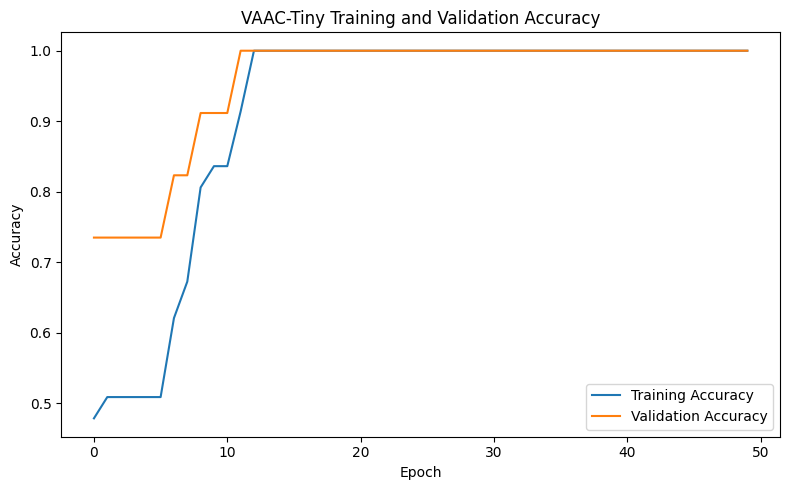

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "VAAC-Tiny Training and Validation Accuracy"
)

plt.legend()

plt.tight_layout()
plt.show()

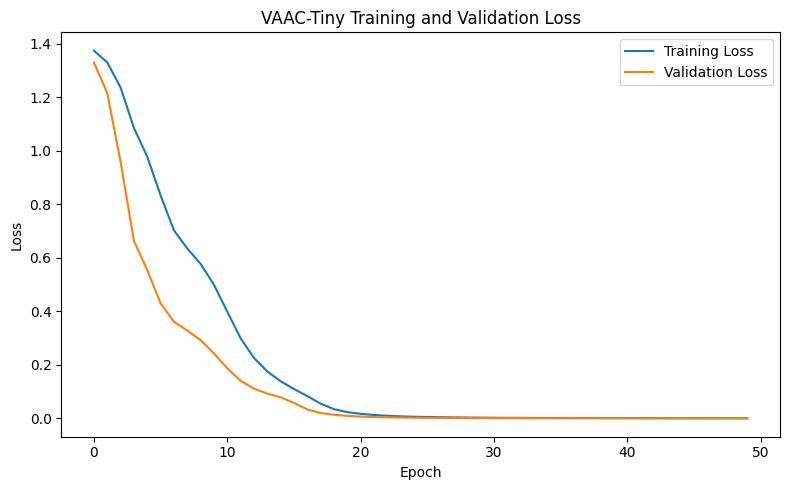

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "VAAC-Tiny Training and Validation Loss"
)

plt.legend()

plt.tight_layout()
plt.show()

In [24]:
history_df = pd.DataFrame(
    history.history
)

history_path = (
    RESULTS_DIR
    / "training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print(
    "Training history saved:"
)

print(
    history_path
)

Training history saved:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\results\vaac_tiny\training_history.csv


In [25]:
print(
    "Best VAAC-Tiny model:"
)

print(
    checkpoint_path
)

print(
    "Exists:",
    checkpoint_path.exists()
)

Best VAAC-Tiny model:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\models\vaac_tiny_best.keras
Exists: True


In [26]:
best_val_accuracy = max(
    history.history["val_accuracy"]
)

best_val_loss = min(
    history.history["val_loss"]
)

epochs_completed = len(
    history.history["loss"]
)

print(
    "VAAC-Tiny Training Summary"
)

print(
    "=========================="
)

print(
    f"Epochs completed: {epochs_completed}"
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.4f}"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

VAAC-Tiny Training Summary
Epochs completed: 50
Best validation accuracy: 1.0000
Best validation loss: 0.0002


In [27]:
best_model_path = (
    PROJECT_ROOT
    / "models"
    / "vaac_tiny_best.keras"
)

best_vaac_model = tf.keras.models.load_model(
    best_model_path
)

print("Best VAAC-Tiny model loaded.")
print(
    "Model path:",
    best_model_path
)

Best VAAC-Tiny model loaded.
Model path: C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\models\vaac_tiny_best.keras


In [28]:
best_vaac_model.summary()

Model: "VAAC_Tiny_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vibration_input     │ (None, 12000, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_conv        │ (None, 12000, 16) │        128 │ vibration_input[… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_3             │ (None, 12000, 16) │        320 │ initial_conv[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_7             │ (None, 12000, 16) │        384 │ initial_conv[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_15            │ (None, 12000, 16) │        512 │ initial_conv[0][… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_scale_fusion  │ (None, 12000, 48) │          0 │ scale_3[0][0],    │
│ (Concatenate)       │                   │            │ scale_7[0][0],    │
│                     │                   │            │ scale_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_refinement  │ (None, 12000, 32) │      1,712 │ multi_scale_fusi… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ feature_refineme… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_features      │ (None, 32)        │      1,056 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_out… │ (None, 4)         │        132 │ dense_features[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,734 (49.75 KB)

 Trainable params: 4,244 (16.58 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,490 (33.17 KB)

In [29]:
test_results = best_vaac_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

test_loss = test_results[0]
test_accuracy = test_results[1]

print("\nVAAC-Tiny Test Results")
print("======================")
print(
    f"Test Loss:     {test_loss:.6f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 1.0000 - loss: 0.0024

VAAC-Tiny Test Results
Test Loss:     0.002442
Test Accuracy: 1.0000


In [30]:
test_probabilities = (
    best_vaac_model.predict(
        X_test,
        verbose=1
    )
)

print(
    "Prediction shape:",
    test_probabilities.shape
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step
Prediction shape: (136, 4)


In [31]:
y_test_pred_vaac = np.argmax(
    test_probabilities,
    axis=1
)

print(
    "Prediction shape:",
    y_test_pred_vaac.shape
)

print(
    "Unique predicted classes:",
    np.unique(y_test_pred_vaac)
)

Prediction shape: (136,)
Unique predicted classes: [0 1 2 3]


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [34]:
vaac_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_vaac
)

print(
    f"VAAC-Tiny Test Accuracy: "
    f"{vaac_test_accuracy:.4f}"
)

VAAC-Tiny Test Accuracy: 1.0000


In [35]:
vaac_precision = precision_score(
    y_test,
    y_test_pred_vaac,
    average="weighted",
    zero_division=0
)

vaac_recall = recall_score(
    y_test,
    y_test_pred_vaac,
    average="weighted",
    zero_division=0
)

vaac_f1 = f1_score(
    y_test,
    y_test_pred_vaac,
    average="weighted",
    zero_division=0
)

print("VAAC-Tiny Test Metrics")
print("======================")
print(
    f"Accuracy : {vaac_test_accuracy:.4f}"
)
print(
    f"Precision: {vaac_precision:.4f}"
)
print(
    f"Recall   : {vaac_recall:.4f}"
)
print(
    f"F1 Score : {vaac_f1:.4f}"
)

VAAC-Tiny Test Metrics
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [36]:
vaac_cm = confusion_matrix(
    y_test,
    y_test_pred_vaac,
    labels=[0, 1, 2, 3]
)

print(
    "VAAC-Tiny Confusion Matrix:"
)

print(vaac_cm)

VAAC-Tiny Confusion Matrix:
[[79  0  0  0]
 [ 0 19  0  0]
 [ 0  0 19  0]
 [ 0  0  0 19]]


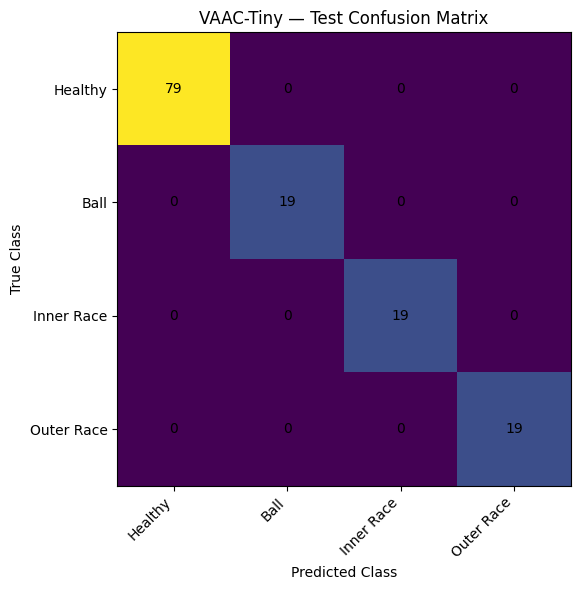

In [37]:
plt.figure(figsize=(7, 6))

plt.imshow(
    vaac_cm
)

plt.title(
    "VAAC-Tiny — Test Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.xticks(
    range(4),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(4),
    CLASS_NAMES
)

for i in range(4):
    for j in range(4):
        plt.text(
            j,
            i,
            vaac_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [38]:
vaac_classification_report = classification_report(
    y_test,
    y_test_pred_vaac,
    labels=[0, 1, 2, 3],
    target_names=CLASS_NAMES,
    zero_division=0
)

print(
    vaac_classification_report
)

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        79
        Ball       1.00      1.00      1.00        19
  Inner Race       1.00      1.00      1.00        19
  Outer Race       1.00      1.00      1.00        19

    accuracy                           1.00       136
   macro avg       1.00      1.00      1.00       136
weighted avg       1.00      1.00      1.00       136



In [39]:
test_prediction_df = test_df.copy()

test_prediction_df[
    "predicted_label"
] = y_test_pred_vaac

test_prediction_df[
    "predicted_class"
] = [
    CLASS_NAMES[i]
    for i in y_test_pred_vaac
]

test_prediction_df[
    "confidence"
] = np.max(
    test_probabilities,
    axis=1
)

for i, class_name in enumerate(
    CLASS_NAMES
):

    test_prediction_df[
        f"prob_{class_name}"
    ] = test_probabilities[:, i]

display(
    test_prediction_df.head()
)

,recording_id,source_file,signal_id,class,window_id,start_sample,end_sample,label,predicted_label,predicted_class,confidence,prob_Healthy,prob_Ball,prob_Inner Race,prob_Outer Race
0,B007_3_X121,B007_3.mat,X121,Ball,0,0,12000,1,1,Ball,0.995831,0.000002,0.995831,0.004162,0.000006
1,B007_3_X121,B007_3.mat,X121,Ball,1,6000,18000,1,1,Ball,0.994963,0.000002,0.994963,0.005030,0.000005
2,B007_3_X121,B007_3.mat,X121,Ball,2,12000,24000,1,1,Ball,0.994040,0.000002,0.994040,0.005954,0.000004
3,B007_3_X121,B007_3.mat,X121,Ball,3,18000,30000,1,1,Ball,0.996120,0.000002,0.996120,0.003872,0.000006
4,B007_3_X121,B007_3.mat,X121,Ball,4,24000,36000,1,1,Ball,0.995702,0.000002,0.995702,0.004291,0.000006


In [40]:
VAAC_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "vaac_tiny"
)

VAAC_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

prediction_path = (
    VAAC_RESULTS_DIR
    / "test_predictions.csv"
)

test_prediction_df.to_csv(
    prediction_path,
    index=False
)

print(
    "Test predictions saved:"
)

print(
    prediction_path
)

Test predictions saved:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\results\vaac_tiny\test_predictions.csv


In [41]:
vaac_metrics = pd.DataFrame([
    {
        "Model": "VAAC-Tiny",
        "Test_Loss": test_loss,
        "Test_Accuracy": vaac_test_accuracy,
        "Test_Precision_Weighted": vaac_precision,
        "Test_Recall_Weighted": vaac_recall,
        "Test_F1_Weighted": vaac_f1
    }
])

display(
    vaac_metrics
)

,Model,Test_Loss,Test_Accuracy,Test_Precision_Weighted,Test_Recall_Weighted,Test_F1_Weighted
0,VAAC-Tiny,0.002442,1.0,1.0,1.0,1.0


In [42]:
vaac_metrics_path = (
    VAAC_RESULTS_DIR
    / "vaac_tiny_test_metrics.csv"
)

vaac_metrics.to_csv(
    vaac_metrics_path,
    index=False
)

print(
    "Metrics saved:"
)

print(
    vaac_metrics_path
)

Metrics saved:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\results\vaac_tiny\vaac_tiny_test_metrics.csv


In [43]:
np.savetxt(
    VAAC_RESULTS_DIR
    / "vaac_tiny_confusion_matrix.csv",
    vaac_cm,
    delimiter=",",
    fmt="%d"
)

print(
    "Confusion matrix saved."
)

Confusion matrix saved.


In [44]:
cnn_confidence = np.max(
    test_probabilities,
    axis=1
)

print(
    "CNN confidence statistics"
)

print(
    "Mean:",
    np.mean(cnn_confidence)
)

print(
    "Minimum:",
    np.min(cnn_confidence)
)

print(
    "Maximum:",
    np.max(cnn_confidence)
)

CNN confidence statistics
Mean: 0.9975697
Minimum: 0.98219174
Maximum: 0.99999654


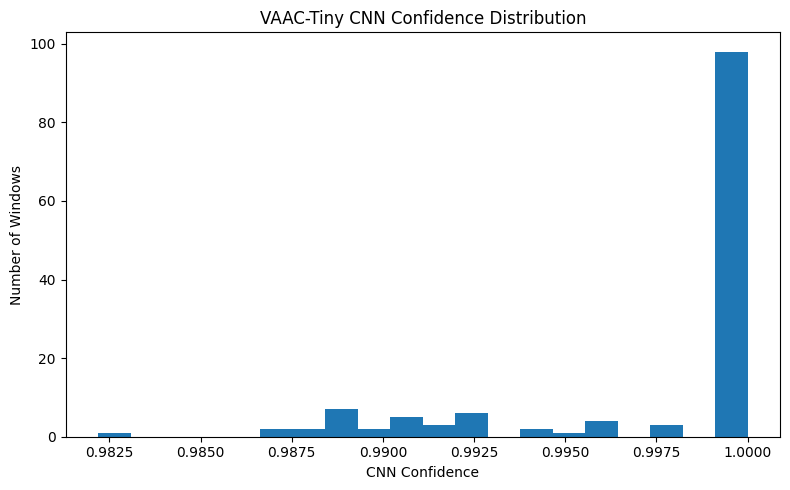

In [45]:
plt.figure(figsize=(8, 5))

plt.hist(
    cnn_confidence,
    bins=20
)

plt.xlabel(
    "CNN Confidence"
)

plt.ylabel(
    "Number of Windows"
)

plt.title(
    "VAAC-Tiny CNN Confidence Distribution"
)

plt.tight_layout()
plt.show()

In [46]:
correct_predictions = (
    y_test_pred_vaac == y_test
)

print(
    "Correct predictions:",
    np.sum(correct_predictions)
)

print(
    "Incorrect predictions:",
    np.sum(
        ~correct_predictions
    )
)

Correct predictions: 136
Incorrect predictions: 0


In [47]:
print(
    "Mean confidence — correct:"
)

print(
    np.mean(
        cnn_confidence[
            correct_predictions
        ]
    )
)

print(
    "\nMean confidence — incorrect:"
)

if np.any(~correct_predictions):

    print(
        np.mean(
            cnn_confidence[
                ~correct_predictions
            ]
        )
    )

else:

    print(
        "No incorrect predictions."
    )

Mean confidence — correct:
0.9975697

Mean confidence — incorrect:
No incorrect predictions.


In [48]:
print("VAAC-Tiny Test Confusion Matrix:")
print(vaac_cm)

VAAC-Tiny Test Confusion Matrix:
[[79  0  0  0]
 [ 0 19  0  0]
 [ 0  0 19  0]
 [ 0  0  0 19]]


In [49]:
print(
    classification_report(
        y_test,
        y_test_pred_vaac,
        labels=[0, 1, 2, 3],
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        79
        Ball       1.00      1.00      1.00        19
  Inner Race       1.00      1.00      1.00        19
  Outer Race       1.00      1.00      1.00        19

    accuracy                           1.00       136
   macro avg       1.00      1.00      1.00       136
weighted avg       1.00      1.00      1.00       136



In [50]:
train_signals = set(
    train_df["signal_id"]
)

test_signals = set(
    test_df["signal_id"]
)

validation_signals = set(
    val_df["signal_id"]
)

print(
    "Train ∩ Validation:",
    train_signals.intersection(
        validation_signals
    )
)

print(
    "Train ∩ Test:",
    train_signals.intersection(
        test_signals
    )
)

print(
    "Validation ∩ Test:",
    validation_signals.intersection(
        test_signals
    )
)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [51]:
signal_results = (
    test_prediction_df
    .groupby(
        [
            "signal_id",
            "class"
        ]
    )
    .agg(
        total_windows=(
            "predicted_class",
            "count"
        ),
        correct_windows=(
            "predicted_class",
            lambda x: (
                x ==
                test_prediction_df
                .loc[
                    x.index,
                    "class"
                ]
            ).sum()
        )
    )
    .reset_index()
)

signal_results["accuracy"] = (
    signal_results["correct_windows"]
    /
    signal_results["total_windows"]
)

display(signal_results)

,signal_id,class,total_windows,correct_windows,accuracy
0,X100,Healthy,79,79,1.0
1,X108,Inner Race,19,19,1.0
2,X121,Ball,19,19,1.0
3,X133,Outer Race,19,19,1.0


In [52]:
cnn_confidence = np.max(
    test_probabilities,
    axis=1
)

print(
    "CNN Confidence Statistics"
)

print(
    "Mean:",
    np.mean(cnn_confidence)
)

print(
    "Minimum:",
    np.min(cnn_confidence)
)

print(
    "Maximum:",
    np.max(cnn_confidence)
)

CNN Confidence Statistics
Mean: 0.9975697
Minimum: 0.98219174
Maximum: 0.99999654


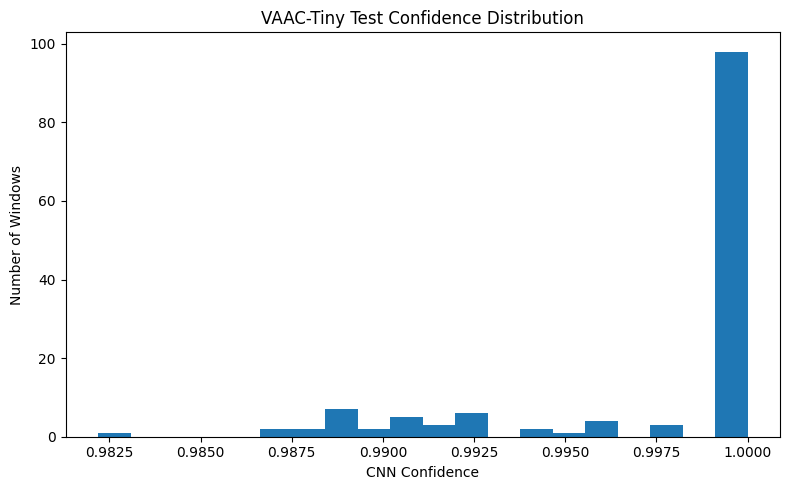

In [53]:
plt.figure(figsize=(8, 5))

plt.hist(
    cnn_confidence,
    bins=20
)

plt.xlabel(
    "CNN Confidence"
)

plt.ylabel(
    "Number of Windows"
)

plt.title(
    "VAAC-Tiny Test Confidence Distribution"
)

plt.tight_layout()
plt.show()